In [ ]:
- **Scheduler (Lên lịch trình tự động)**
	+ Tự động làm việc gì đó cho chúng ta
	+ Tự động lên trình cụ thẻ vào giây, giờ, phút nào..
	+ VD: Mỗi đêm lên lịch để backup Database

- Lên lịch là như thế nào:
	- Không cần phía client gửi request lên Server
	- VD: Muốn server xử lý để tạo thêm một bài blog, phía Client gửi request với method [POST], nếu tạo thành công trở về status `201` chuẩn Restful API
	> Tức là chúng ta (client) phải có một yêu cầu (request) lên server rồi nó mới xử lý
	> Còn nếu không có bất cứ request nào đến server thì server sẽ không xử lý

- Schedule:
	+ Là một thứ chạy trên server
	+ Không liên quan đến Client, không cần request từ Client
	+ Cứ tự động chạy, giống như đồng hồ báo thức (Đến giờ đấy, thì thực hiện một thao tác gì đấy)
	> Phù hợp cho những công việc đòi hỏi tính tự động, mà không cần đến bàn tay của con người. 
	> VD: Cứ 2h sáng, chúng ta backup DATABASE để tránh rủi ro về database
	> Backup Database là gì?
		+ Đóng gói thành một file SQL. Tại Navicat -> chuột phải vào Database -> Dumb SQL File -> Structure And Data --> Kết quả: File `chat_dev2.sql`
		+ Nếu chẳng may Database lỗi --> Chuột vào Db -> Execute Sql File -> Mở file backup `chat_dev2.sql`

	VD2: Những việc tự động:
		+ Tự động viết blog với AI

In [ ]:
# GIẢI THÍCH KHÁI NIỆM SCHEDULE (CRON JOB)
1. **Nỗi đau (Pain Point)**
- Hãy tưởng tượng em đang làm một hệ thống thương mại điện tử. Cứ mỗi 12h đêm, em phải:
	+ Quét toàn bộ đơn hàng chưa thanh toán để hủy.
	+ Gửi email chúc mừng sinh nhật cho khách hàng.
	+ Backup dữ liệu từ Database ra file dự phòng.

- Chẳng lẽ 12h đêm nào em cũng phải thức dậy, mở máy tính lên và bấm một cái nút "Chạy" sao? Hay em dùng setTimeout? Nếu server bị restart thì setTimeout nó "bay màu" luôn, chưa kể viết logic cực kỳ loằng ngoằng. Đó chính là lúc chúng ta thấy "khổ".

2. **Giải pháp (Solution)**
Schedule (thường dùng thư viện `node-cron` trong Node.js) sinh ra để giải quyết việc này. Nó giúp em **đặt lịch** cho code: "Đúng giờ này, ngày này, hãy thực hiện hàm này cho tôi". Em chỉ cần viết code một lần, nó sẽ tự chạy mãi mãi theo chu kỳ.

3. **Khái niệm & Tại sao (ELI5)**
- Nói đơn giản: **Schedule là một cái đồng hồ báo thức** dành cho Server.
Thay vì báo thức để em dậy đi học, nó "báo thức" để một đoạn code nhảy vào thực thi.

4. **Phân tích cú pháp (Syntax)**
- Trong Node.js, phổ biến nhất là `node-cron`. Cú pháp của nó dựa trên 5 hoặc 6 dấu sao (* * * * *):
```text
# ┌────────────── second (optional)
 # │ ┌──────────── minute
 # │ │ ┌────────── hour
 # │ │ ┌────────── day of month
 # │ │ │ ┌──────── month
 # │ │ │ │ ┌────── day of week
 # │ │ │ │ │
 # │ │ │ │ │
 # * * * * * *
```

5. **Ẩn dụ (Analogy)**
- Hãy nghĩ về game Liên Quân Mobile:
	- **Lính (Minions)**: Cứ mỗi 30 giây lại xuất hiện một đợt lính (Schedule theo chu kỳ ngắn).
	- **Tà thần Caesar**: Xuất hiện đúng vào phút thứ 2:00, 8:00 và 15:00 (Schedule theo thời điểm cố định).
	- **Quà đăng nhập ngày**: Đúng 00:00 hệ thống reset để em nhận quà (Schedule hàng ngày).
- Admin game không hề ngồi bấm nút thả lính, tất cả đều là Schedule đã được lập trình sẵn!

In [ ]:
# Khái niệm Cron Job/Tab
- Là tên một chương trình, cho chúng ta thiết lập một khoảng thời gian.
- Đến đúng khoảng thời gian đấy theo đồng hồ của máy tính thì nó sẽ thực hiện một công việc gì đó thực hiện một lệnh gì đó (VD: Mở file, thực thi file nào đó)

In [ ]:
# GIẢI THÍCH KHÁI NIỆM CRON JOB
1. **Nỗi đau (Pain Point)**
Trong lập trình, có những việc em không muốn làm ngay lúc khách hàng bấm nút, mà em muốn nó **tự chạy định kỳ**.
- Ví dụ: Em dùng `setInterval` để cứ 1 tiếng quét dữ liệu một lần. Nhưng nếu em muốn nó chạy đúng **2h sáng thứ Hai hàng tuần** thì `setInterval` chịu chết.
- Chưa kể, `setInterval` chạy dựa trên thời điểm em bật server. Nếu em bật lúc 10h sáng thì nó tính 1 tiếng từ lúc đó, cực kỳ khó kiểm soát chính xác theo lịch thực tế.

2. **Giải pháp (Solution)**
- `Cron Job` là một tiêu chuẩn của hệ điều hành (gốc từ Unix) dùng để **lập lịch cho các tác vụ**. Nó cho phép em chỉ định **chính xác đến từng phút, từng giờ, ngày, tháng** để code được thực thi. Nó sinh ra để giúp hệ thống tự vận hành mà không cần con người "canh giờ".

3. **Khái niệm & Tại sao (ELI5)**
- Hãy coi Cron Job là một "**Trợ lý ảo**" cực kỳ đúng giờ. Em đưa cho người trợ lý này một tờ giấy ghi: "`Cứ 8h sáng hàng ngày, hãy pha cà phê cho tôi`". Đúng 8h, dù em đang ngủ, đang tắm hay đang leo rank, cà phê vẫn sẽ được pha.

4. **Phân tích cú pháp (Syntax)**
- Cú pháp của Cron Job thường là một chuỗi có 5 hoặc 6 ký tự dấu sao. Đây là phần "khó nhằn" nhất nhưng cũng thú vị nhất:

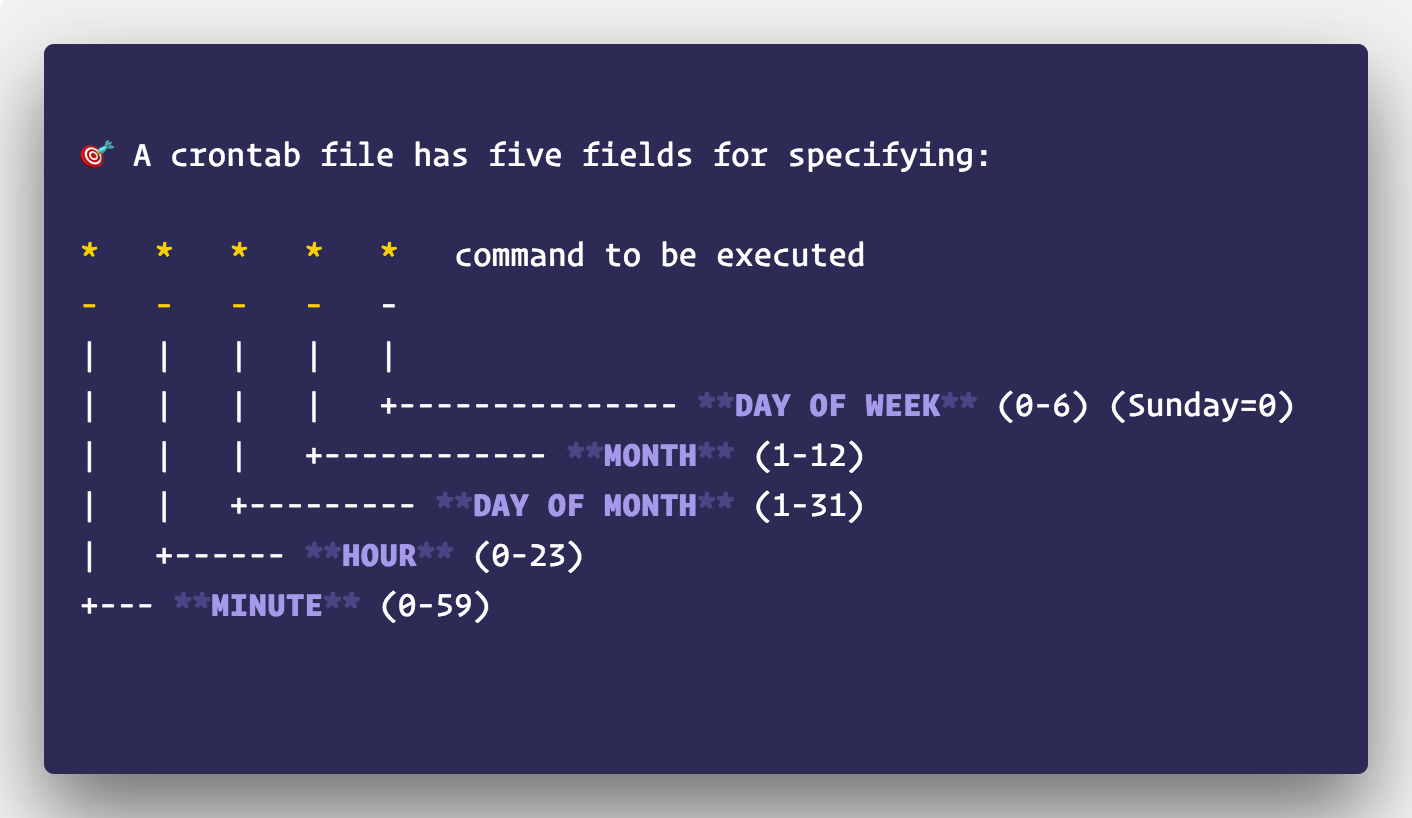

In [ ]:
Cấu trúc: `* * * * *`
1. Phút (0 - 59)
2. Giờ (0 - 23)
3. Ngày trong tháng (1 - 31)
4. Tháng (1 - 12)
5. Ngày trong tuần (0 - 6, với 0 là Chủ Nhật)
---
Ví dụ: `30 8 * * *` có nghĩa là: **8h30 sáng mỗi ngày**.

# Mẹo nhớ "Thần thánh" (ELI5)
Em hãy nhớ cụm từ viết tắt này cho anh: "M-H-D-M-W".
Để cho dễ nhớ hơn nữa, hãy dùng câu tiếng Việt này: "`M`ình `H`ọc `D`ữ `M`ới `W`in".

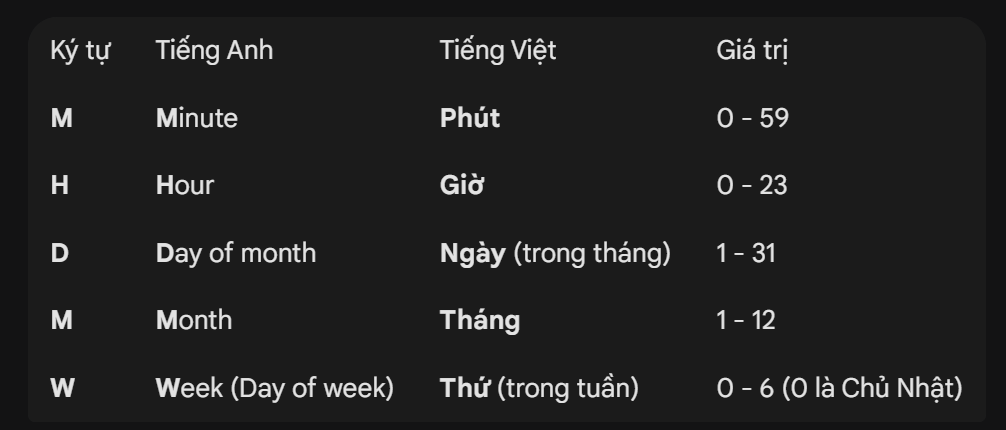

In [ ]:
3. **Các "Ký hiệu đặc biệt" cần nhớ**
- Ngoài con số, Cron Job còn có 4 "pháp bảo" sau:
	- `*` (Dấu sao): **Tất cả**. (Cứ đúng...)
	- `,` (Dấu phẩy): **Và**. (Chọn danh sách cụ thể, ví dụ: `1,3,5` là thứ 2, 4, 6).
	- `-` (Dấu gạch ngang): **Đến**. (Khoảng thời gian, ví dụ: `1-5` là từ thứ 2 đến thứ 6).
	- `/` (Dấu xuyệt): **Mỗi khoảng**/Cứ mỗi. (Ví dụ: `*/15` ở cột Phút là cứ mỗi 15 phút một lần).

# THỰC HÀNH "ĐỌC MẬT MÃ"
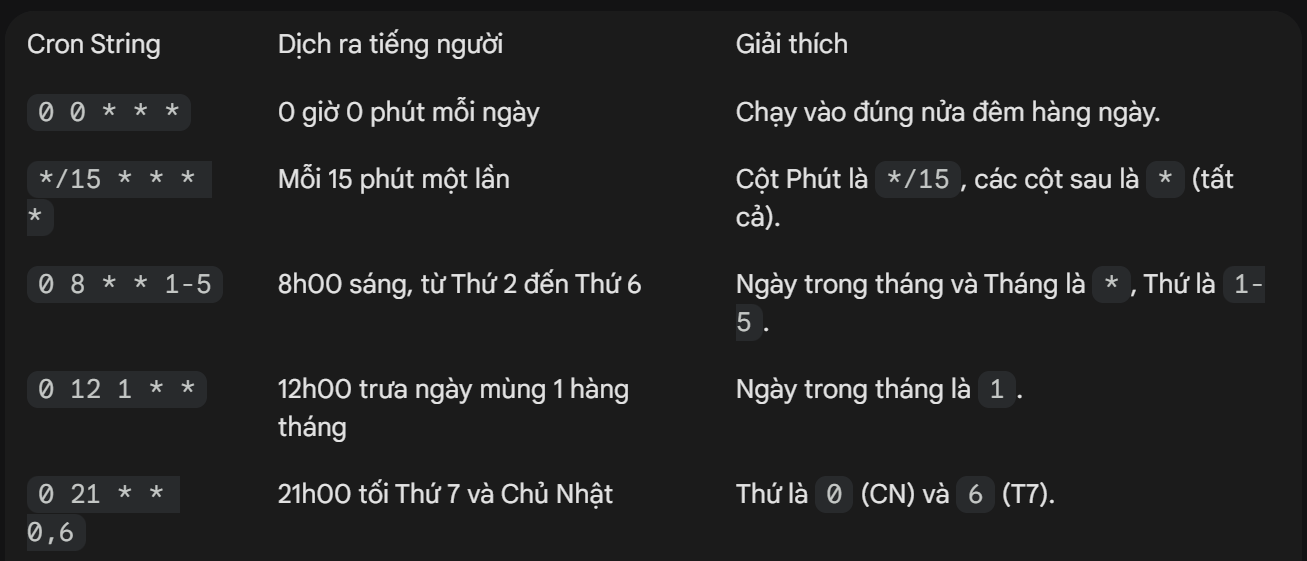

- `15 * * * *`: Cứ đúng phút thứ 15
- `*/15 * * * *`: Cứ mỗi 15 phút

In [ ]:
# Phần thực thi sau khi xác định thời gian chạy chu kỳ
- Chúng ta đã setup thời gian
- Vậy thời gian đó chúng ta sẽ làm gì?
> Chạy lệnh trong terminal (Command to be executed)
> VD: `node abc.js`

In [ ]:
# Cài đặt
npm install cron

In [ ]:
1. **Nỗi đau (Pain Point)**
- Khi làm hệ thống lớn, anh em mình thường gặp 2 cái khổ cực lớn với thời gian:
  - **Múi giờ (Timezone)**: Server của em đặt ở Mỹ (UTC), nhưng em muốn gửi thông báo cho người dùng Việt Nam lúc 8h sáng giờ Hà Nội. Tính toán cộng trừ 7 tiếng thủ công cực kỳ dễ sai.
  - **Độ chính xác đến từng giây**: Một số tác vụ như bắn thông báo Flash Sale cần chính xác đến từng giây, không thể đợi đến đầu phút mới chạy.

2. **Giải pháp (Solution)**
- Thư viện `cron` sinh ra để giải quyết triệt để việc này. Nó cung cấp một Class CronJob mạnh mẽ, hỗ trợ **6 dấu sao (thêm cột giây)** và tích hợp sẵn thư viện Luxon để xử lý múi giờ cực chuẩn.

3. **Khái niệm & Tại sao (ELI5)**
- Nếu `node-cron` là cái đồng hồ báo thức treo tường bình thường, thì thư viện cron này giống như một chiếc Smartwatch cao cấp. Nó không chỉ `báo thức đúng giờ` mà còn biết `tự đổi múi giờ` khi em bay sang nước khác và `có kim giây` chạy cực kỳ chính xác.

4. **Phân tích cú pháp (Syntax)**
*Điểm khác biệt lớn nhất là nó có 6 vị trí (thay vì 5 như thông thường):*
`* * * * * *`:
  - Giây (0-59) - *Điểm mới!*
  - Phút (0-59)
  - Giờ (0-23)
  - Ngày trong tháng (1-31)
  - Tháng (1-12 hoặc tên tiếng Anh)
  - Ngày trong tuần (0-6, 0 là Chủ Nhật)